# Симуляция распространения инфекции по сети аэропортов

**Домашнее задание №4 — NetworkX и SI-модель**

В работе выполнены все три части задания:

1. реализована событийная SI-симуляция распространения инфекции по рейсам;
2. исследовано влияние вероятности заражения $p$ на скорость эпидемии;
3. построен взвешенный граф аэропортов и исследована связь времени заражения с кластеризацией, степенью и betweenness centrality.

Все эксперименты воспроизводимы: для генератора случайных чисел заданы фиксированные seed. Ноутбук рассчитан на запуск рядом с файлом `2008.csv`.

## Методические решения и допущения

- В описании задания сказано, что данные относятся к одному месяцу, однако файл `2008.csv` содержит весь 2008 год. Поэтому анализ ограничен **январём 2008 года** (`ANALYSIS_MONTH = 1`).
- Allentown соответствует IATA-коду **ABE**.
- Исключены отменённые и перенаправленные рейсы, а также строки без фактического времени вылета или длительности полёта.
- Момент прилёта вычисляется как фактический момент вылета плюс `ActualElapsedTime`; это корректно обрабатывает перелёты через полночь.
- Используется строгая временная логика: самолёт переносит инфекцию, только если аэропорт отправления уже был заражён **к моменту вылета**. Успешное заражение аэропорта назначения фиксируется **в момент прилёта**.
- SI-модель не предусматривает выздоровление: заражённый аэропорт остаётся заражённым до конца наблюдения.

Такой событийный подход устраняет «заглядывание в будущее», которое возникло бы при простом обходе строк без обработки прилётов в хронологическом порядке.

In [1]:
from collections import defaultdict
from heapq import heappop, heappush
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('2008.csv')
ANALYSIS_MONTH = 1
START_AIRPORT = 'ABE'  # Allentown–Bethlehem–Easton
MASTER_SEED = 20260719

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Файл {DATA_PATH.resolve()} не найден')


## 1. Подготовка данных

In [2]:
USECOLS = [
    'Year', 'Month', 'DayofMonth', 'DepTime', 'ActualElapsedTime',
    'Origin', 'Dest', 'Cancelled', 'Diverted'
]

def load_month_flights(path, month=1, chunksize=500_000):
    """Читает большой CSV частями и оставляет валидные рейсы выбранного месяца."""
    parts = []
    total_rows = 0
    for chunk in pd.read_csv(path, usecols=USECOLS, chunksize=chunksize, low_memory=False):
        total_rows += len(chunk)
        part = chunk.loc[chunk['Month'].eq(month)].copy()
        if not part.empty:
            parts.append(part)

    flights = pd.concat(parts, ignore_index=True)
    valid = (
        flights['Cancelled'].eq(0)
        & flights['Diverted'].eq(0)
        & flights['DepTime'].notna()
        & flights['ActualElapsedTime'].gt(0)
        & flights['Origin'].notna()
        & flights['Dest'].notna()
    )
    flights = flights.loc[valid].copy()

    calendar_date = pd.to_datetime(
        dict(
            year=flights['Year'].astype('int16'),
            month=flights['Month'].astype('int8'),
            day=flights['DayofMonth'].astype('int8'),
        )
    )
    hhmm = flights['DepTime'].astype('int32')
    dep_minutes = (hhmm // 100) * 60 + (hhmm % 100)
    flights['departure_time'] = calendar_date + pd.to_timedelta(dep_minutes, unit='m')
    flights['arrival_time'] = flights['departure_time'] + pd.to_timedelta(
        flights['ActualElapsedTime'], unit='m'
    )

    flights = (
        flights[['Origin', 'Dest', 'departure_time', 'arrival_time']]
        .sort_values(['departure_time', 'arrival_time'], kind='mergesort')
        .reset_index(drop=True)
    )
    return flights, total_rows


flights, rows_in_file = load_month_flights(DATA_PATH, ANALYSIS_MONTH)
airports = np.array(sorted(set(flights['Origin']) | set(flights['Dest'])))
airport_to_id = {airport: i for i, airport in enumerate(airports)}

flights['origin_id'] = flights['Origin'].map(airport_to_id).astype('int16')
flights['dest_id'] = flights['Dest'].map(airport_to_id).astype('int16')

SIMULATION_START = pd.Timestamp(2008, ANALYSIS_MONTH, 1)
SIMULATION_END = flights['arrival_time'].max()

print(f'Строк в исходном файле: {rows_in_file:,}')
print(f'Валидных рейсов за январь: {len(flights):,}')
print(f'Число аэропортов: {len(airports)}')
print(f'Интервал наблюдения: {SIMULATION_START} — {SIMULATION_END}')
print(f'Рейсы из/в ABE: {(flights.Origin.eq(START_AIRPORT)).sum():,} / '
      f'{(flights.Dest.eq(START_AIRPORT)).sum():,}')

display(flights.head())


Строк в исходном файле: 7,009,728
Валидных рейсов за январь: 587,130
Число аэропортов: 286
Интервал наблюдения: 2008-01-01 00:00:00 — 2008-02-01 08:16:00
Рейсы из/в ABE: 383 / 391


,Origin,Dest,departure_time,arrival_time,origin_id,dest_id
0,MDW,MCI,2008-01-01 00:01:00,2008-01-01 01:17:00,168,164
1,MDW,BWI,2008-01-01 00:01:00,2008-01-01 01:28:00,168,45
2,ATL,CHS,2008-01-01 00:02:00,2008-01-01 00:57:00,16,54
3,DEN,FLL,2008-01-01 00:02:00,2008-01-01 03:29:00,77,100
4,PDX,JFK,2008-01-01 00:02:00,2008-01-01 05:36:00,203,141


## Часть 1. Функция SI-симуляции

Для эффективных многократных прогонов категориальные коды и времена переводятся в массивы NumPy. Очередь ожидаемых успешных заражений — min-heap, упорядоченный по времени прилёта.

Функция `simulate_si(start_airport, p, seed)` возвращает требуемый словарь **`{время заражения: аэропорт}`**. Если несколько аэропортов заражаются в одну и ту же минуту, к повторному ключу добавляется только техническая наносекунда, чтобы словарь не потерял событие; сама временная шкала данных имеет минутную точность.

In [3]:
origin_ids = flights['origin_id'].to_numpy(dtype=np.int16)
dest_ids = flights['dest_id'].to_numpy(dtype=np.int16)
departure_ns = flights['departure_time'].astype('int64').to_numpy()
arrival_ns = flights['arrival_time'].astype('int64').to_numpy()

N_AIRPORTS = len(airports)
START_NS = SIMULATION_START.value
NOT_INFECTED = np.iinfo(np.int64).max


def _simulate_infection_times(start_airport, p, seed=None):
    """Возвращает массив истинных времён заражения в наносекундах."""
    if start_airport not in airport_to_id:
        raise ValueError(f'Неизвестный аэропорт: {start_airport}')
    if not 0 <= p <= 1:
        raise ValueError('Вероятность p должна находиться в диапазоне [0, 1]')

    rng = np.random.default_rng(seed)
    infected = np.zeros(N_AIRPORTS, dtype=bool)
    infection_time = np.full(N_AIRPORTS, NOT_INFECTED, dtype=np.int64)
    start_id = airport_to_id[start_airport]
    infected[start_id] = True
    infection_time[start_id] = START_NS
    infected_count = 1

    # (время прилёта, id назначения) для успешных передач инфекции
    pending_arrivals = []

    for origin, dest, departure, arrival in zip(
        origin_ids, dest_ids, departure_ns, arrival_ns
    ):
        # Сначала применяем все заражения, случившиеся к текущему вылету.
        while pending_arrivals and pending_arrivals[0][0] <= departure:
            event_time, airport_id = heappop(pending_arrivals)
            if not infected[airport_id]:
                infected[airport_id] = True
                infection_time[airport_id] = event_time
                infected_count += 1

        if infected_count == N_AIRPORTS:
            break

        # Статус origin проверяется в момент вылета; заражение dest — при прилёте.
        if infected[origin] and not infected[dest] and rng.random() < p:
            heappush(pending_arrivals, (int(arrival), int(dest)))

    # Применяем успешные заражения от последних рейсов наблюдаемого периода.
    while pending_arrivals and infected_count < N_AIRPORTS:
        event_time, airport_id = heappop(pending_arrivals)
        if not infected[airport_id]:
            infected[airport_id] = True
            infection_time[airport_id] = event_time
            infected_count += 1

    return infection_time


def simulate_si(start_airport, p, seed=None):
    """Один проход SI-модели; результат: {время заражения: аэропорт}."""
    infection_time = _simulate_infection_times(start_airport, p, seed)
    result = {}
    for airport_id in np.argsort(infection_time):
        time_ns = infection_time[airport_id]
        if time_ns == NOT_INFECTED:
            break
        timestamp = pd.Timestamp(int(time_ns))
        # Не теряем одновременные события из-за уникальности ключей dict.
        while timestamp in result:
            timestamp += pd.Timedelta(1, unit='ns')
        result[timestamp] = str(airports[airport_id])
    return result


def history_to_series(history):
    """Преобразует словарь событий в Series: индекс=аэропорт, значение=время."""
    result = pd.Series(pd.NaT, index=airports, dtype='datetime64[ns]')
    for timestamp, airport in history.items():
        result.loc[airport] = timestamp
    return result


In [4]:
# Проверки граничных случаев и демонстрационный прогон
history_p0 = simulate_si(START_AIRPORT, p=0.0, seed=MASTER_SEED)
history_demo = simulate_si(START_AIRPORT, p=0.5, seed=MASTER_SEED)
history_p1 = simulate_si(START_AIRPORT, p=1.0, seed=MASTER_SEED)

assert history_p0 == {SIMULATION_START: START_AIRPORT}
assert len(history_demo) <= N_AIRPORTS
assert all(a in airport_to_id for a in history_demo.values())
assert list(history_demo) == sorted(history_demo)

print(f'p=0.0: заражено {len(history_p0)} из {N_AIRPORTS}')
print(f'p=0.5: заражено {len(history_demo)} из {N_AIRPORTS}')
print(f'p=1.0: заражено {len(history_p1)} из {N_AIRPORTS}')
display(pd.DataFrame(list(history_demo.items())[:10], columns=['infection_time', 'airport']))


p=0.0: заражено 1 из 286
p=0.5: заражено 286 из 286
p=1.0: заражено 286 из 286


,infection_time,airport
0,2008-01-01 00:00:00,ABE
1,2008-01-01 08:06:00,DTW
2,2008-01-01 09:45:00,PIT
3,2008-01-01 09:47:00,ELM
4,2008-01-01 09:53:00,CMH
5,2008-01-01 10:22:00,LEX
6,2008-01-01 10:32:00,CLT
7,2008-01-01 10:51:00,MSN
8,2008-01-01 10:52:00,HSV
9,2008-01-01 10:53:00,BWI


## Часть 2. Влияние вероятности заражения

In [5]:
PROBABILITIES = [0.01, 0.05, 0.10, 0.50, 1.00]
N_RUNS_PART2 = 10

part2_histories = {}
for p_index, p in enumerate(PROBABILITIES):
    part2_histories[p] = [
        simulate_si(
            START_AIRPORT,
            p,
            seed=MASTER_SEED + 1_000 + p_index * 100 + run,
        )
        for run in range(N_RUNS_PART2)
    ]

print(f'Выполнено {len(PROBABILITIES) * N_RUNS_PART2} симуляций.')


Выполнено 50 симуляций.


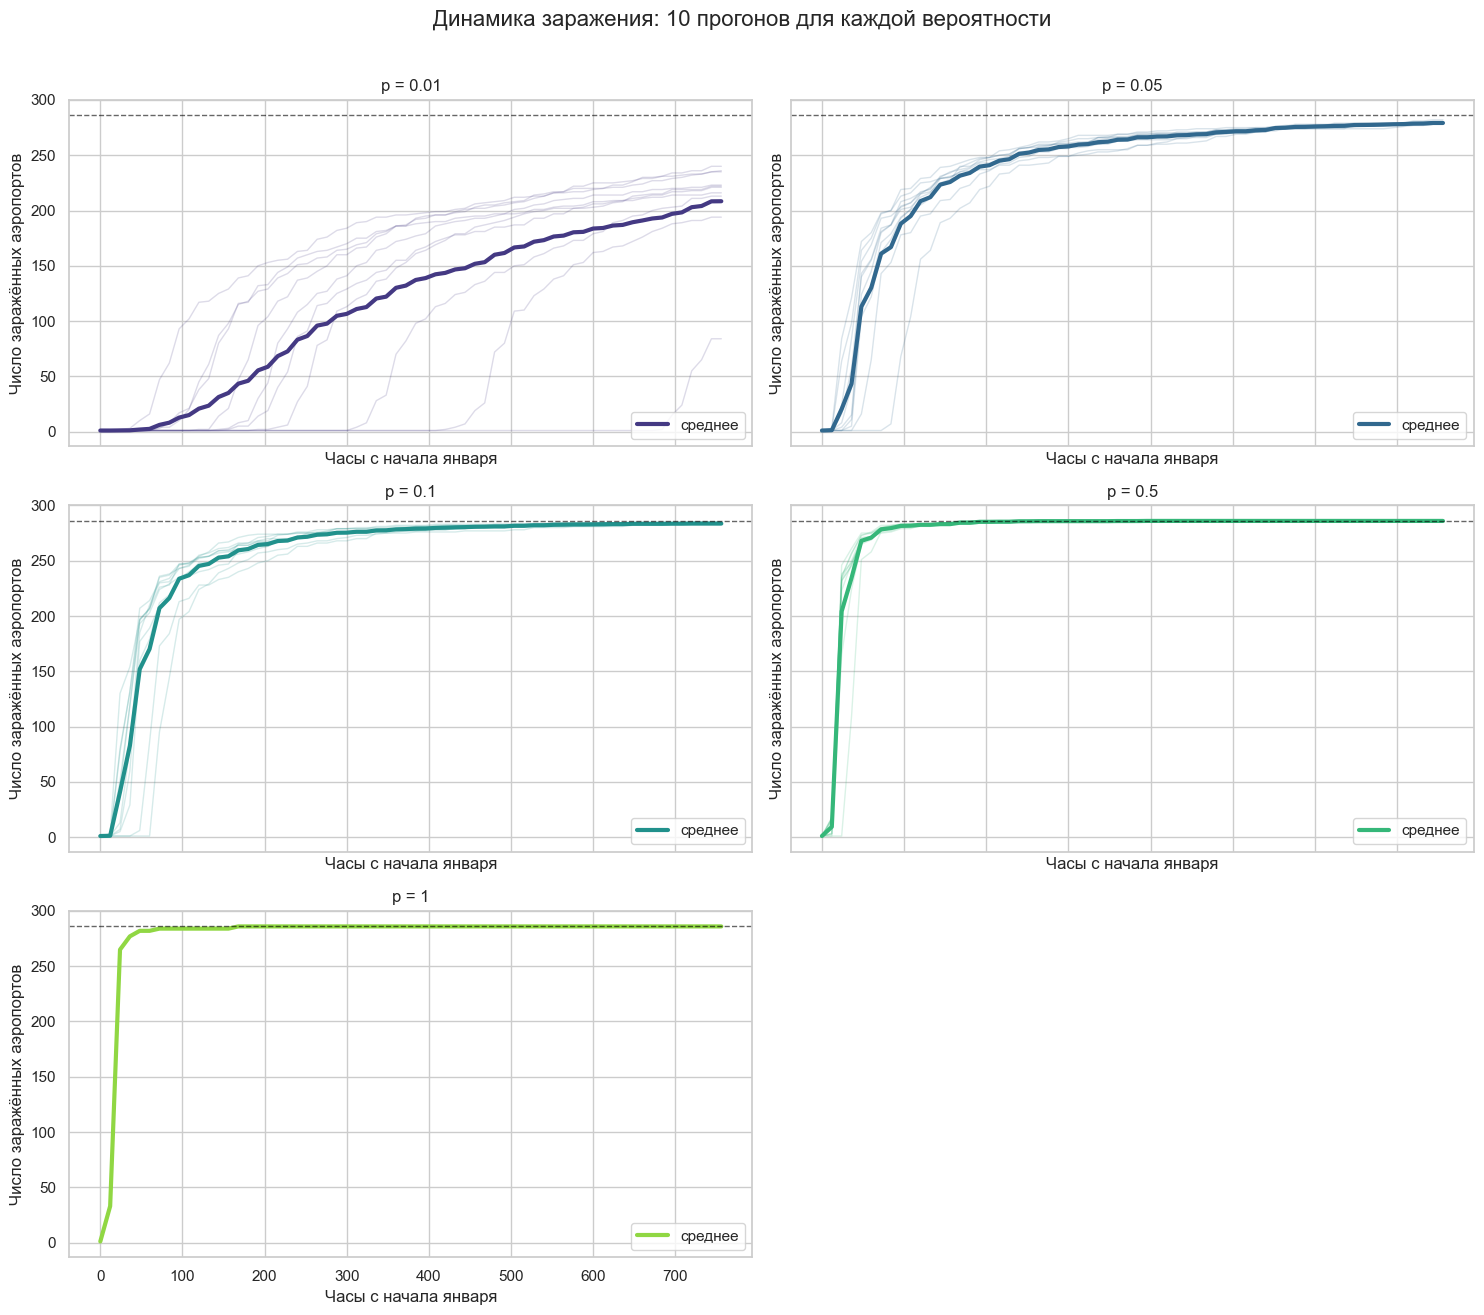

In [6]:
# Каждые 12 часов считаем накопленное число и процент заражённых аэропортов.
grid_end = SIMULATION_END.ceil('12h')
time_grid = pd.date_range(SIMULATION_START, grid_end, freq='12h')
grid_ns = time_grid.astype('int64').to_numpy()

curve_records = []
for p, histories in part2_histories.items():
    for run, history in enumerate(histories, start=1):
        infected_ns = np.sort(np.array([t.value for t in history], dtype=np.int64))
        counts = np.searchsorted(infected_ns, grid_ns, side='right')
        curve_records.extend(
            {
                'p': p,
                'run': run,
                'time': time,
                'hours': (time - SIMULATION_START).total_seconds() / 3600,
                'infected': int(count),
                'percent': 100 * count / N_AIRPORTS,
            }
            for time, count in zip(time_grid, counts)
        )

curves = pd.DataFrame(curve_records)
mean_curves = (
    curves.groupby(['p', 'time', 'hours'], as_index=False)
    .agg(mean_infected=('infected', 'mean'), mean_percent=('percent', 'mean'))
)

fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True, sharey=True)
axes = axes.ravel()
palette = sns.color_palette('viridis', len(PROBABILITIES))

for ax, p, color in zip(axes, PROBABILITIES, palette):
    subset = curves[curves['p'].eq(p)]
    for _, run_data in subset.groupby('run'):
        ax.plot(run_data['hours'], run_data['infected'], color=color, alpha=0.18, lw=1)
    mean_data = mean_curves[mean_curves['p'].eq(p)]
    ax.plot(mean_data['hours'], mean_data['mean_infected'], color=color, lw=3, label='среднее')
    ax.axhline(N_AIRPORTS, color='black', ls='--', lw=1, alpha=0.6)
    ax.set_title(f'p = {p:g}')
    ax.set_xlabel('Часы с начала января')
    ax.set_ylabel('Число заражённых аэропортов')
    ax.legend(loc='lower right')

axes[-1].axis('off')
fig.suptitle('Динамика заражения: 10 прогонов для каждой вероятности', y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


In [7]:
# Сводка: итоговая доля, число полных эпидемий и время достижения 50% сети.
summary_rows = []
for p in PROBABILITIES:
    p_curves = curves[curves['p'].eq(p)]
    final = p_curves.sort_values('time').groupby('run').tail(1)
    half_times = []
    for run, run_data in p_curves.groupby('run'):
        reached = run_data[run_data['infected'].ge(N_AIRPORTS / 2)]
        half_times.append(reached['hours'].iloc[0] if not reached.empty else np.nan)
    summary_rows.append(
        {
            'p': p,
            'среднее заражено, %': final['percent'].mean(),
            'минимум заражено, %': final['percent'].min(),
            'максимум заражено, %': final['percent'].max(),
            'полностью заражена сеть, прогонов из 10': int(final['infected'].eq(N_AIRPORTS).sum()),
            'медиана времени до 50%, часов': np.nanmedian(half_times) if np.isfinite(half_times).any() else np.nan,
        }
    )

part2_summary = pd.DataFrame(summary_rows).set_index('p')
display(part2_summary.style.format('{:.2f}', subset=[
    'среднее заражено, %', 'минимум заражено, %', 'максимум заражено, %',
    'медиана времени до 50%, часов'
]))

full_candidates = part2_summary[
    part2_summary['полностью заражена сеть, прогонов из 10'].eq(N_RUNS_PART2)
]
if full_candidates.empty:
    threshold_text = 'Ни одна из проверенных вероятностей не заразила всю сеть во всех 10 прогонах.'
else:
    threshold_p = full_candidates.index.min()
    threshold_text = (
        f'Минимальная из проверенных вероятностей, при которой вся сеть была заражена '
        f'во всех 10 прогонах: **p = {threshold_p:g}**.'
    )

display(Markdown(f"""### Ответ на вопрос части 2

{threshold_text}

При увеличении $p$ кривые становятся круче, половина сети заражается раньше, а итоговая доля заражённых растёт. Причина — у каждого заражённого аэропорта больше успешных передач на исходящих рейсах; после заражения хабов одновременно открывается много новых путей распространения. При малых $p$ значительная часть потенциально заразных рейсов не передаёт инфекцию до окончания окна наблюдения, поэтому сеть может остаться заражённой не полностью.

Светлые линии на графиках — отдельные случайные прогоны, жирная линия — среднее по 10 симуляциям. Проценты и число полных заражений приведены в таблице выше.
"""))


,"среднее заражено, %","минимум заражено, %","максимум заражено, %","полностью заражена сеть, прогонов из 10","медиана времени до 50%, часов"
p,,,,,
0.010000,72.87,29.37,83.92,0,312.00
0.050000,97.62,97.20,98.60,0,60.00
0.100000,99.16,98.95,99.65,0,48.00
0.500000,100.00,100.00,100.00,10,24.00
1.000000,100.00,100.00,100.00,10,24.00


### Ответ на вопрос части 2

Минимальная из проверенных вероятностей, при которой вся сеть была заражена во всех 10 прогонах: **p = 0.5**.

При увеличении $p$ кривые становятся круче, половина сети заражается раньше, а итоговая доля заражённых растёт. Причина — у каждого заражённого аэропорта больше успешных передач на исходящих рейсах; после заражения хабов одновременно открывается много новых путей распространения. При малых $p$ значительная часть потенциально заразных рейсов не передаёт инфекцию до окончания окна наблюдения, поэтому сеть может остаться заражённой не полностью.

Светлые линии на графиках — отдельные случайные прогоны, жирная линия — среднее по 10 симуляциям. Проценты и число полных заражений приведены в таблице выше.


## Часть 3. Граф сети и предсказание времени заражения

### Построение ненаправленного взвешенного графа

Для каждой неупорядоченной пары аэропортов суммируется число рейсов в обоих направлениях. В соответствии с заданием:

$$w_{AB}=\frac{n_{A\to B}+n_{B\to A}}{N_{\text{всех рейсов}}}.$$

Кроме `weight` сохраняются число рейсов `flights` и `distance = 1 / flights`. Последняя величина нужна для взвешенной betweenness centrality: NetworkX трактует вес кратчайшего пути как **длину**, тогда как частота рейсов является **силой связи**. Поэтому частому сообщению ставится меньшая эффективная длина.

In [8]:
edge_frame = flights[['Origin', 'Dest']].copy()
edge_frame['source'] = np.minimum(edge_frame['Origin'], edge_frame['Dest'])
edge_frame['target'] = np.maximum(edge_frame['Origin'], edge_frame['Dest'])
edge_counts = (
    edge_frame.loc[edge_frame['source'].ne(edge_frame['target'])]
    .groupby(['source', 'target'])
    .size()
    .rename('flights')
    .reset_index()
)

total_flights = len(flights)
G = nx.Graph()
G.add_nodes_from(airports)
for row in edge_counts.itertuples(index=False):
    G.add_edge(
        row.source,
        row.target,
        flights=int(row.flights),
        weight=row.flights / total_flights,
        distance=1.0 / row.flights,
    )

assert G.number_of_nodes() == N_AIRPORTS
assert np.isclose(sum(d['weight'] for _, _, d in G.edges(data=True)), 1.0)

print(f'Узлов: {G.number_of_nodes()}, рёбер: {G.number_of_edges():,}')
print(f'Компонент связности: {nx.number_connected_components(G)}')
print(f'Сумма весов рёбер: {sum(d["weight"] for _, _, d in G.edges(data=True)):.6f}')


Узлов: 286, рёбер: 2,319
Компонент связности: 1
Сумма весов рёбер: 1.000000


In [9]:
N_RUNS_PART3 = 50
part3_histories = [
    simulate_si(START_AIRPORT, p=0.5, seed=MASTER_SEED + 20_000 + run)
    for run in range(N_RUNS_PART3)
]

infection_matrix = pd.concat(
    [history_to_series(history).rename(f'run_{run + 1}')
     for run, history in enumerate(part3_histories)],
    axis=1,
)
infection_hours = infection_matrix.apply(
    lambda column: (column - SIMULATION_START).dt.total_seconds() / 3600
)

# Незаражённый до конца наблюдения аэропорт — правое цензурирование (условно +inf).
# Если хотя бы половина прогонов не достигла аэропорта, медиана считается не достигнутой.
censored = infection_hours.fillna(np.inf).to_numpy()
median_hours_values = np.median(censored, axis=1)
median_hours_values[~np.isfinite(median_hours_values)] = np.nan
median_infection_hours = pd.Series(median_hours_values, index=infection_hours.index)

coverage = infection_hours.notna().sum(axis=1)
print(f'Выполнено {N_RUNS_PART3} симуляций при p=0.5.')
print(f'Среднее число заражённых за прогон: '
      f'{infection_hours.notna().sum(axis=0).mean():.1f} из {N_AIRPORTS}')
print(f'Аэропортов с определимой медианой: {median_infection_hours.notna().sum()} из {N_AIRPORTS}')


Выполнено 50 симуляций при p=0.5.
Среднее число заражённых за прогон: 286.0 из 286
Аэропортов с определимой медианой: 286 из 286


In [10]:
# Метрики графа для каждого аэропорта.
clustering = nx.clustering(G, weight='weight')
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G, weight='distance', normalized=True)

metrics = pd.DataFrame({
    'median_infection_hours': median_infection_hours,
    'clustering': pd.Series(clustering),
    'degree': pd.Series(degree),
    'betweenness': pd.Series(betweenness),
    'infected_runs': coverage,
})

# Стартовый ABE исключаем из корреляций: его время принудительно равно нулю.
analysis_metrics = metrics.drop(index=START_AIRPORT).dropna(subset=['median_infection_hours'])

metric_labels = {
    'clustering': 'Взвешенный коэффициент кластеризации',
    'degree': 'Степень узла',
    'betweenness': 'Betweenness centrality (1 / число рейсов)',
}

correlation_rows = []
for metric, label in metric_labels.items():
    rho, p_value = spearmanr(
        analysis_metrics['median_infection_hours'], analysis_metrics[metric],
        nan_policy='omit'
    )
    correlation_rows.append({
        'metric': metric,
        'метрика': label,
        'Spearman rho': rho,
        'p-value': p_value,
        'n': len(analysis_metrics),
    })

correlations = pd.DataFrame(correlation_rows).set_index('metric')
display(correlations[['метрика', 'Spearman rho', 'p-value', 'n']].style.format({
    'Spearman rho': '{:.4f}', 'p-value': '{:.3g}'
}))

display(metrics.sort_values('median_infection_hours').head(10))


,метрика,Spearman rho,p-value,n
metric,,,,
clustering,Взвешенный коэффициент кластеризации,-0.4080,7.41e-13,285
degree,Степень узла,-0.7940,3.99e-63,285
betweenness,Betweenness centrality (1 / число рейсов),-0.2998,2.51e-07,285


,median_infection_hours,clustering,degree,betweenness,infected_runs
ABE,0.0000,0.0599,7,0.0000,50
DTW,10.2583,0.0251,111,0.0450,50
ORD,10.7667,0.0254,142,0.2815,50
CLT,11.0167,0.0519,69,0.0070,50
IND,12.3833,0.0814,32,0.0000,50
CVG,12.6250,0.0245,96,0.0000,50
PHL,12.7000,0.0700,50,0.0000,50
DCA,12.7167,0.0658,47,0.0000,50
RDU,12.7500,0.0741,42,0.0000,50
ATL,12.8667,0.0201,166,0.4592,50


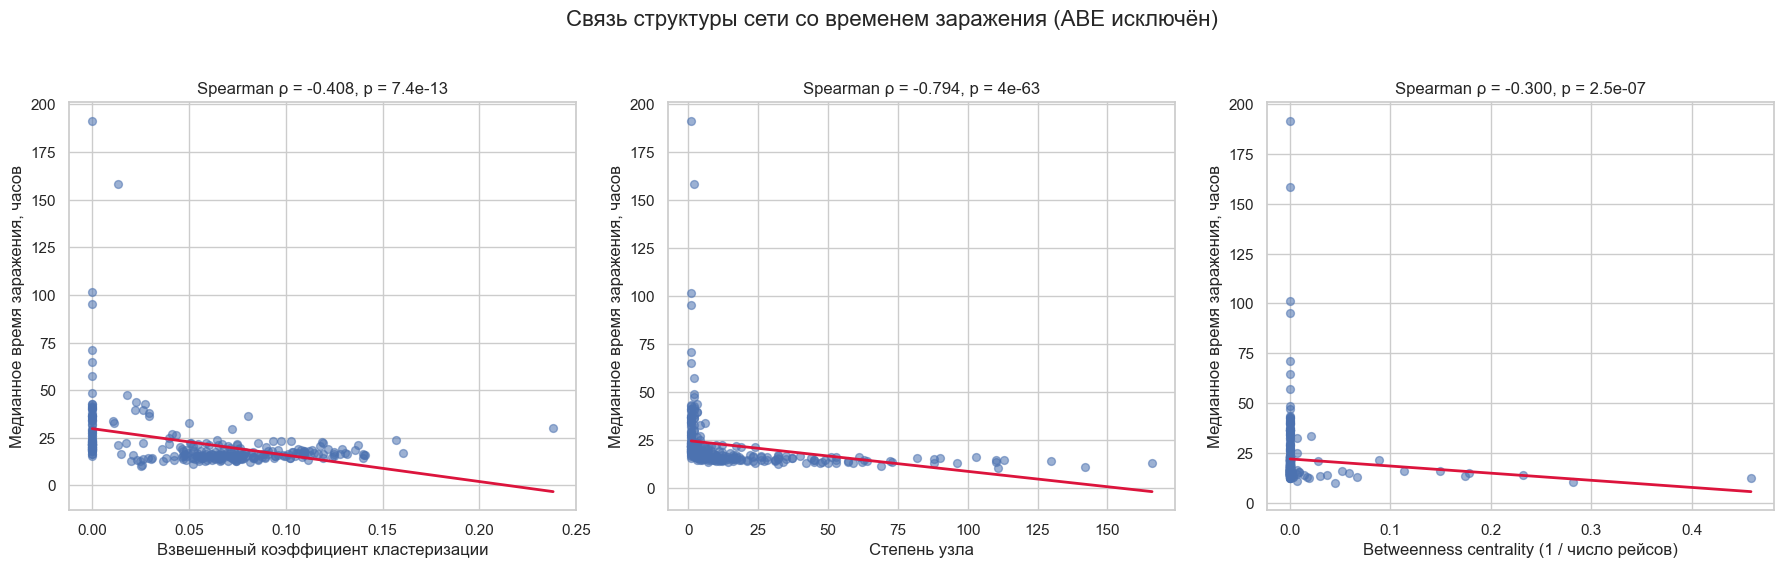

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (metric, label) in zip(axes, metric_labels.items()):
    sns.regplot(
        data=analysis_metrics,
        x=metric,
        y='median_infection_hours',
        scatter_kws={'alpha': 0.55, 's': 32},
        line_kws={'color': 'crimson', 'lw': 2},
        ci=None,
        ax=ax,
    )
    rho = correlations.loc[metric, 'Spearman rho']
    p_value = correlations.loc[metric, 'p-value']
    ax.set_title(f'Spearman ρ = {rho:.3f}, p = {p_value:.2g}')
    ax.set_xlabel(label)
    ax.set_ylabel('Медианное время заражения, часов')

fig.suptitle('Связь структуры сети со временем заражения (ABE исключён)', y=1.03, fontsize=16)
fig.tight_layout()
plt.show()


In [12]:
strongest_metric = correlations['Spearman rho'].abs().idxmax()
strongest_label = metric_labels[strongest_metric]
strongest_rho = correlations.loc[strongest_metric, 'Spearman rho']

mechanisms = {
    'degree': (
        'У узла высокой степени много различных соседей, поэтому существует больше независимых '
        'возможностей получить инфекцию ранним входящим рейсом.'
    ),
    'betweenness': (
        'Высокая посредническая центральность означает положение на множестве эффективных маршрутов '
        'между частями сети; такие транзитные узлы чаще встречают волну распространения раньше.'
    ),
    'clustering': (
        'Высокая кластеризация означает включённость в плотное локальное окружение, где много '
        'альтернативных путей передачи инфекции.'
    ),
}

sign_text = 'раньше' if strongest_rho < 0 else 'позже'
display(Markdown(fr"""### Ответ на вопрос части 3

Сильнее всего с медианным временем заражения связана метрика **{strongest_label}**: коэффициент Спирмена $\rho={strongest_rho:.3f}$. Знак корреляции показывает, что при росте этой метрики аэропорты в среднем заражаются **{sign_text}**.

{mechanisms[strongest_metric]}

Корреляция Спирмена сравнивает ранги и потому подходит лучше линейной корреляции: зависимость не обязана быть линейной, времена дискретны, а сетевые метрики имеют скошенные распределения. Стартовый аэропорт ABE исключён из расчёта корреляций, потому что его нулевое время задано конструкцией эксперимента, а не объясняется структурой графа.

Важно: это статистическая связь, а не полноценная предсказательная модель. Время заражения определяется не только топологией агрегированного графа, но и расписанием рейсов, направлением конкретного рейса и случайными передачами. Поэтому даже сильная топологическая метрика не объясняет всю вариативность.
"""))


### Ответ на вопрос части 3

Сильнее всего с медианным временем заражения связана метрика **Степень узла**: коэффициент Спирмена $\rho=-0.794$. Знак корреляции показывает, что при росте этой метрики аэропорты в среднем заражаются **раньше**.

У узла высокой степени много различных соседей, поэтому существует больше независимых возможностей получить инфекцию ранним входящим рейсом.

Корреляция Спирмена сравнивает ранги и потому подходит лучше линейной корреляции: зависимость не обязана быть линейной, времена дискретны, а сетевые метрики имеют скошенные распределения. Стартовый аэропорт ABE исключён из расчёта корреляций, потому что его нулевое время задано конструкцией эксперимента, а не объясняется структурой графа.

Важно: это статистическая связь, а не полноценная предсказательная модель. Время заражения определяется не только топологией агрегированного графа, но и расписанием рейсов, направлением конкретного рейса и случайными передачами. Поэтому даже сильная топологическая метрика не объясняет всю вариативность.


## Итоговые выводы

1. Событийная SI-модель корректно учитывает направление и время каждого рейса: заражение не может передаваться рейсом, который вылетел до заражения аэропорта отправления.
2. Инфекционность $p$ управляет не только наклоном эпидемической кривой, но и вероятностью охватить всю сеть за конечный месяц наблюдения.
3. Сетевые метрики содержат полезный сигнал о времени заражения: хабы и транзитные аэропорты обычно получают больше ранних возможностей встретить заражённый рейс.
4. Агрегированный граф теряет временной порядок рейсов, поэтому для точного прогноза топологические признаки следует дополнять признаками расписания и интенсивности входящего трафика.